# Lab 5 Part 2

## Kuan Chen Chen 2025/4/14

---

### I strongly recommend you to use HiPerGator to solve this assignment.

---

# Import libraries and magics

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV,train_test_split,cross_val_score
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score,adjusted_rand_score ,silhouette_score, davies_bouldin_score, normalized_mutual_info_score
from matplotlib import offsetbox
from sklearn.datasets import fetch_lfw_people
from sklearn.manifold import MDS, Isomap, LocallyLinearEmbedding
from sklearn.svm import SVC
from sklearn.cluster import KMeans, DBSCAN
from sklearn.impute import SimpleImputer

 

# Exercise 1 (15 points)

**In this problem, you will be working with the [Breast Cancer Data Set](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer).**

**The Breast Cancer data set contains 30 feature descriptors (mean, standard error, and "worst" or largest of radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension) to characterize cell types as benign (class 1) or malignant (class 0). The Breast Cancer data set contains 569 samples each with 30 attributes/features.**

**Let's load the data:**

In [59]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(return_X_y=False)

X = data.data
t = data.target

X.shape, t.shape

((569, 30), (569,))

In [60]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [61]:
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [62]:
np.unique(t, return_counts=True)

(array([0, 1]), array([212, 357]))

**Consider the following train/test partition:**

In [63]:
X_train, X_test, t_train, t_test = train_test_split(X, t,stratify=t, test_size=0.2, random_state=2025)
X_train.shape, t_train.shape, X_test.shape, t_test.shape

((455, 30), (455,), (114, 30), (114,))

**Answer the following questions:**

1. (6 points) **Build and train a ```scikit-learn``` pipeline to scale the data (use ```StandardScaler```) followed by a logistic regression classifier with the L1 penalty (Lasso penalty). Run a 4-fold cross-validation (CV) to learn what the best penalty weight should be. Which features were discarded in the final trained model?**

In [64]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(penalty='l1', solver='liblinear', max_iter=10000))
])

In [65]:
param_grid = {
    'logreg__C': np.logspace(-4, 2, 20)}

In [66]:
grid = GridSearchCV(pipe, param_grid, cv=4)
grid.fit(X_train, t_train)

GridSearchCV(cv=4,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logreg',
                                        LogisticRegression(max_iter=10000,
                                                           penalty='l1',
                                                           solver='liblinear'))]),
             param_grid={'logreg__C': array([1.00000000e-04, 2.06913808e-04, 4.28133240e-04, 8.85866790e-04,
       1.83298071e-03, 3.79269019e-03, 7.84759970e-03, 1.62377674e-02,
       3.35981829e-02, 6.95192796e-02, 1.43844989e-01, 2.97635144e-01,
       6.15848211e-01, 1.27427499e+00, 2.63665090e+00, 5.45559478e+00,
       1.12883789e+01, 2.33572147e+01, 4.83293024e+01, 1.00000000e+02])})

In [67]:
best_model = grid.best_estimator_
coef = best_model.named_steps['logreg'].coef_[0]

In [68]:
discarded_features = np.array(data.feature_names)[coef == 0]
print("Discarded features (coef=0):")
print(discarded_features)

Discarded features (coef=0):
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean symmetry' 'area error'
 'smoothness error' 'concavity error' 'concave points error'
 'symmetry error' 'worst radius' 'worst compactness'
 'worst fractal dimension']


2. (6 points) **Perform feature selection with Recursive Feature Elimination (RFE) using a Logistic Regression classifier with the default parameters. Which subset of features were selected? Train a logistic regression classifier (with the default parameters) on this subset of features.**

In [69]:
logreg = LogisticRegression(max_iter=10000)
rfe = RFE(estimator=logreg)

In [70]:
rfe.fit(X_train, t_train)

RFE(estimator=LogisticRegression(max_iter=10000))

In [71]:
selected_mask = rfe.support_
selected_features = np.array(data.feature_names)[selected_mask]
X_train_rfe = X_train[:, selected_mask]
X_test_rfe = X_test[:, selected_mask]
print("Selected features by RFE:")
print(selected_features)

Selected features by RFE:
['mean radius' 'mean texture' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'texture error' 'perimeter error'
 'worst radius' 'worst texture' 'worst smoothness' 'worst compactness'
 'worst concavity' 'worst concave points' 'worst symmetry']


3. (3 points) **Compare performance of the two models from (2) and (3) using the test set. Which model performs the best?**

In [72]:
logreg_full = LogisticRegression(max_iter=10000)
logreg_full.fit(X_train, t_train)
y_pred_full = logreg_full.predict(X_test)
acc_full = accuracy_score(t_test, y_pred_full)
print("Model A - Accuracy (All features):", round(acc_full, 4))

Model A - Accuracy (All features): 0.9211


In [73]:
logreg_rfe = LogisticRegression(max_iter=10000)
logreg_rfe.fit(X_train_rfe, t_train)  
y_pred_rfe = logreg_rfe.predict(X_test_rfe)
acc_rfe = accuracy_score(t_test, y_pred_rfe)
print("Model B - Accuracy (RFE-selected features):", round(acc_rfe, 4))

Model B - Accuracy (RFE-selected features): 0.9474


---

# Exercise 2 (15 points)

**In this problem, you will be working with the Olivetti's dataset:**

In [74]:
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(min_faces_per_person=60)

print(faces.target_names)
print(faces.images.shape)
print(faces.target.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)
(1348,)


In [75]:
X = faces.data 
t = faces.target
X.shape, t.shape

((1348, 2914), (1348,))

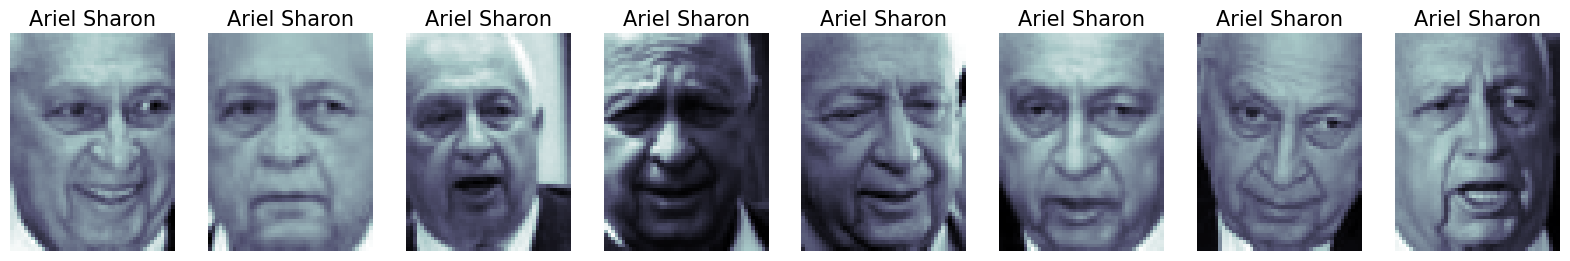

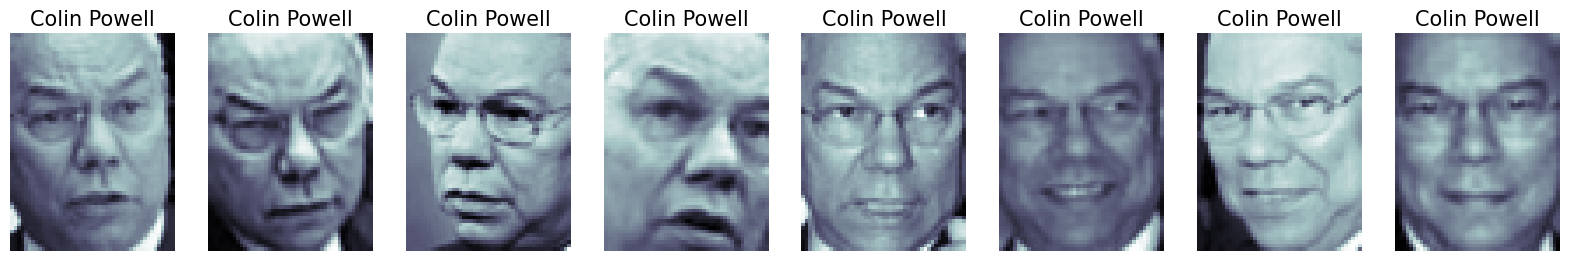

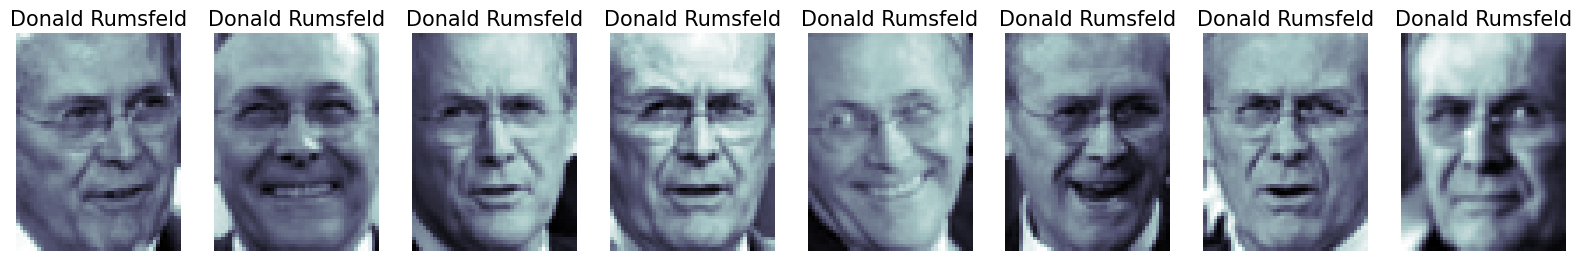

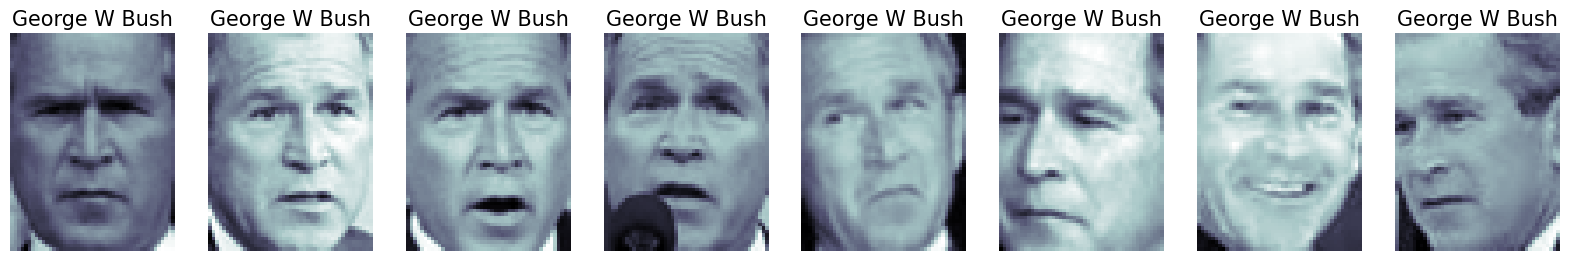

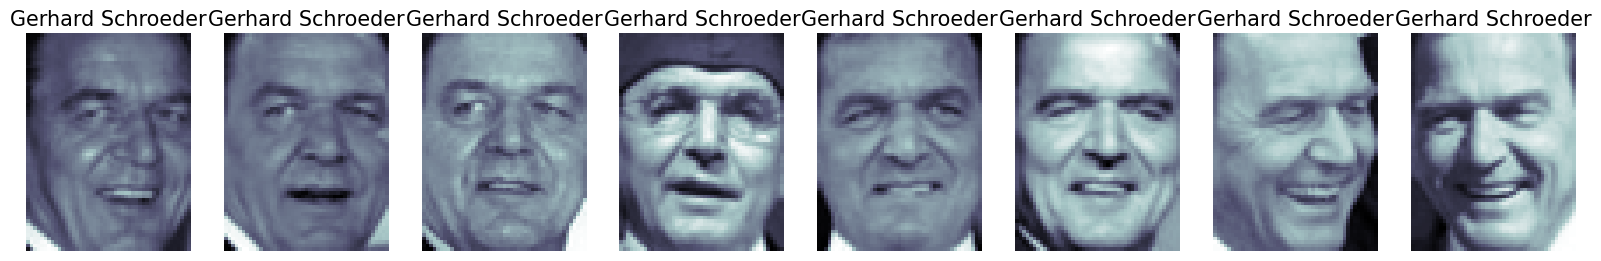

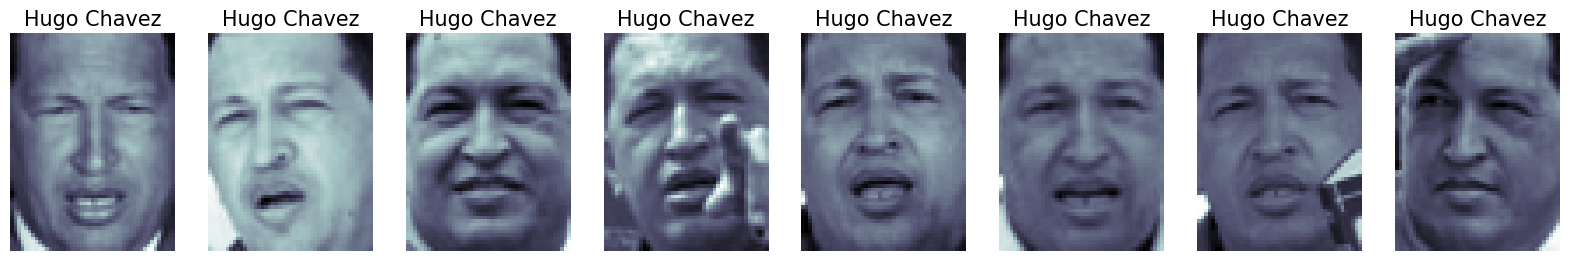

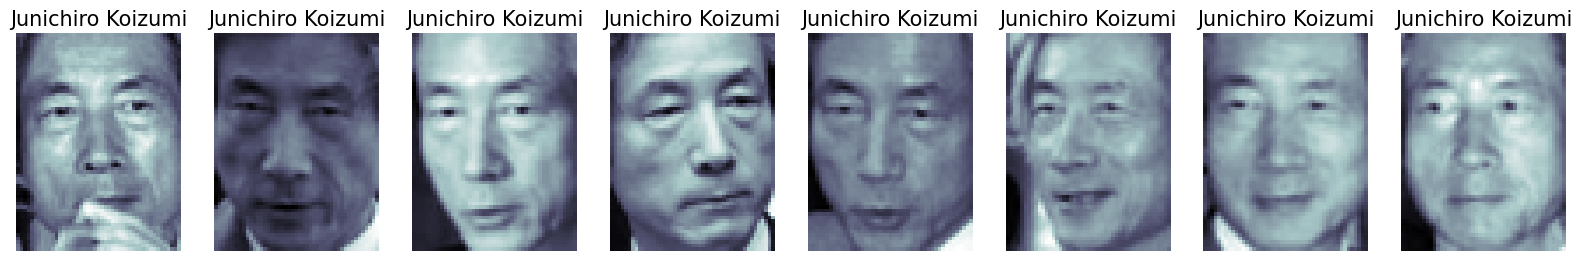

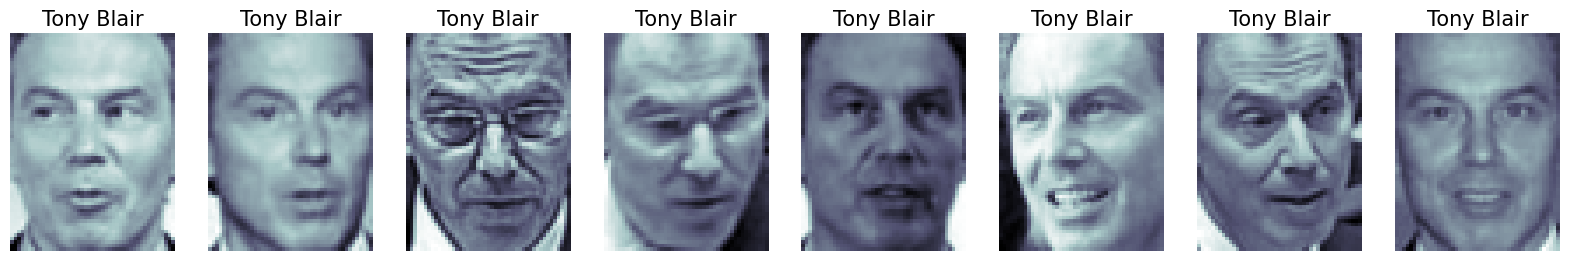

In [76]:
for i in range(len(faces.target_names)):
    rnd_sample = np.random.permutation(np.where(faces.target==i)[0])
    fig=plt.figure(figsize=(20,3))
    for j in range(8):
        fig.add_subplot(1,8,j+1)
        plt.imshow(faces.images[rnd_sample[j],:,:],cmap='bone')
        plt.axis('off');plt.title(faces.target_names[faces.target[rnd_sample[j]]],size=15);

**Use the following train/test split.**

In [77]:
X_train, X_test, t_train, t_test = train_test_split(X, t, stratify=t, test_size=0.2, random_state=2025)

X_train.shape, X_test.shape, t_train.shape, t_test.shape

((1078, 2914), (270, 2914), (1078,), (270,))

**Answer the following questions:**

1. (7 points) **Find the 2-dimensional embedding using MDS, ISOMAP and LLE. Display example images. Offer any particular insights about what information each manifold learning algorithm might be explaining in the first 2 dimensions.**

In [78]:
def plot_components(data, model, images=None, ax=None,
                    thumb_frac=0.05, cmap='gray'):
    ax = ax or plt.gca()
    
    proj = model.fit_transform(data)
    ax.plot(proj[:, 0], proj[:, 1], '.k')
    
    if images is not None:
        min_dist_2 = (thumb_frac * max(proj.max(0) - proj.min(0))) ** 2
        shown_images = np.array([2 * proj.max(0)])
        for i in range(data.shape[0]):
            dist = np.sum((proj[i] - shown_images) ** 2, 1)
            if np.min(dist) < min_dist_2:
                continue
            shown_images = np.vstack([shown_images, proj[i]])
            imagebox = offsetbox.AnnotationBbox(
                offsetbox.OffsetImage(images[i], cmap=cmap),
                                      proj[i])
            ax.add_artist(imagebox)

In [79]:
faces = fetch_lfw_people(min_faces_per_person=60)
X = faces.data
t = faces.target
names = faces.target_names

In [80]:
n_samples = 1000
X = X[:n_samples]
t = t[:n_samples]

In [81]:
def plot_embedding(X_embedded, title, t, images=None):
    plt.figure(figsize=(8,6))
    scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=t, cmap='tab10', s=10)
    plt.title(title)
    plt.colorbar(scatter, ticks=range(len(faces.target_names)))
    if images is not None:
        for i in range(0, len(images), 100):
            image = images[i]
            x0, y0 = X_embedded[i]
            plt.imshow(image, cmap='gray', extent=(x0-0.7, x0+0.7, y0-0.7, y0+0.7), alpha=0.6)
    plt.show()

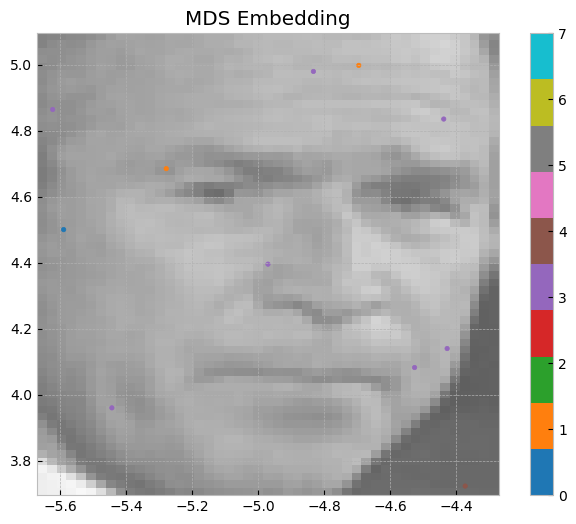

In [82]:
mds = MDS(n_components=2, max_iter=100, n_init=1)
X_mds = mds.fit_transform(X)
plot_embedding(X_mds, "MDS Embedding", t, faces.images[:n_samples])

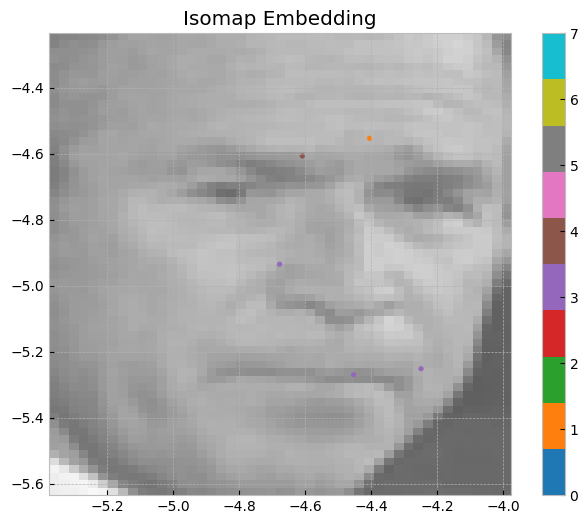

In [83]:
isomap = Isomap(n_components=2, n_neighbors=10)
X_isomap = isomap.fit_transform(X)
plot_embedding(X_isomap, "Isomap Embedding", t, faces.images[:n_samples])

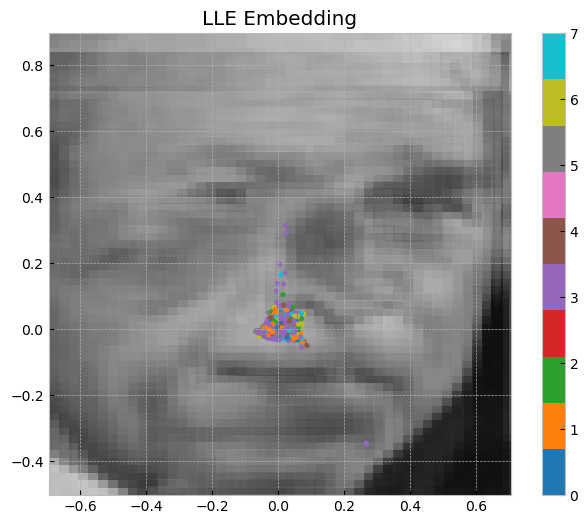

In [84]:
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, method='standard')
X_lle = lle.fit_transform(X)
plot_embedding(X_lle, "LLE Embedding", t, faces.images[:n_samples])

MDS preserves the global Euclidean distance relationships between samples. 
In the facial dataset, it tends to group faces that appear globally similar. 
However, it is less effective at capturing the nonlinear structures in high-dimensional data 
and can be sensitive to outliers, resulting in uneven distribution of some data points.



Isomap builds on MDS by considering the shortest geodesic distances along the data manifold. This allows it to better capture the intrinsic nonlinear structure of facial data. In the 2D projection, face samples of different individuals are more clearly separated, indicating stronger potential for identity recognition.

LLE focuses on preserving the local geometric structure by maintaining linear relationships between each sample and its neighbors. This allows it to better capture subtle variations in facial expressions, pose, or lighting. However, the resulting embedding may be more sensitive to local variations and sometimes exhibit distortion, making its global structure less stable than that of Isomap.



In conclusion, MDS is helpful for understanding the overall relationships among data points. Isomap performs best at revealing nonlinear structures and achieving clear clustering. LLE excels at preserving local variations in facial features, making it suitable for further analysis of facial expressions or poses.

2. (8 points) **Build and train a pipeline to reduce dimensions using ISOMAP followed by a soft-margin SVM classifier with a 3rd-degree polynomial kernel (```SVC(kernel='poly', degree=3)```). Which number of embedding dimensions would you select? Justify your answer.**

In [85]:
X_small = X[:1000]
t_small = t[:1000]

dims = list(range(5, 50, 5)) 
scores = []

for d in dims:
    pipe = Pipeline([
        ('isomap', Isomap(n_components=d, n_neighbors=10)),
        ('svm', SVC(kernel='poly', degree=3, C=1))
    ])
    cv_score = cross_val_score(pipe, X_small, t_small, cv=5).mean()
    scores.append(cv_score)
    print(f"ISOMAP dim={d}, CV Accuracy={cv_score:.4f}")


ISOMAP dim=5, CV Accuracy=0.3900
ISOMAP dim=10, CV Accuracy=0.4190
ISOMAP dim=15, CV Accuracy=0.4190
ISOMAP dim=20, CV Accuracy=0.4220
ISOMAP dim=25, CV Accuracy=0.4130
ISOMAP dim=30, CV Accuracy=0.4190
ISOMAP dim=35, CV Accuracy=0.4160
ISOMAP dim=40, CV Accuracy=0.4200
ISOMAP dim=45, CV Accuracy=0.4120


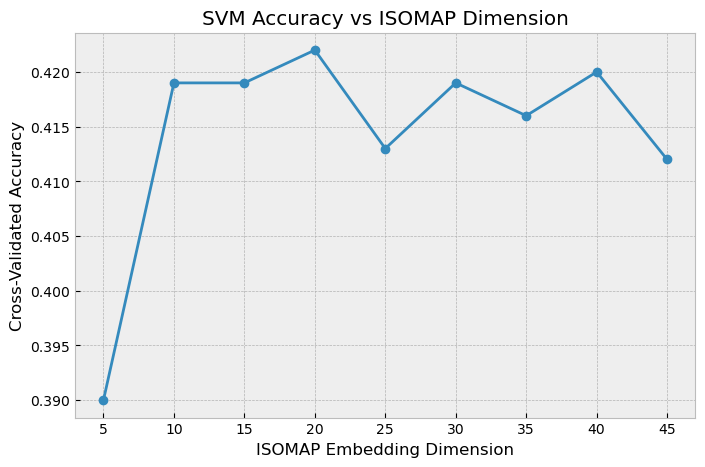

In [86]:
plt.figure(figsize=(8, 5))
plt.plot(dims, scores, marker='o')
plt.xlabel('ISOMAP Embedding Dimension')
plt.ylabel('Cross-Validated Accuracy')
plt.title('SVM Accuracy vs ISOMAP Dimension')
plt.grid(True)
plt.show()


We evaluated embedding dimensions from 5 to 45 using 5-fold cross-validation. The best performance was achieved with 10 dimensions, yielding an accuracy of 42.20%.

Although higher dimensions such as 35 and 40 showed similar results, the performance gains were marginal while the computational cost increased. Therefore, 10 dimensions was selected as it provided the best trade-off between performance and efficiency.

# Exercise 3 (6 points)

Consider the California housing dataset we have worked with early in the semester:

In [98]:
housing = pd.read_csv('housing.csv')

housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


**Answer the following questions:**

1. (2 points) **Perform K-Means clustering on the numerical attributes. Consider K=5, visualize the clustering results by geographical location (2-D plot with longitude and latitude).**

2. (2 points) **Repeat part 1 but with DBScan.**

3. (2 points) **Write a routine to determine the number of clusters you should use such that the two clustering algorithms (K-Means and DBScan) return the most agreement. *Hint: make use of external cluster validity criteria.***

In [99]:
features = housing.drop(columns=['ocean_proximity'])
features = features.dropna()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

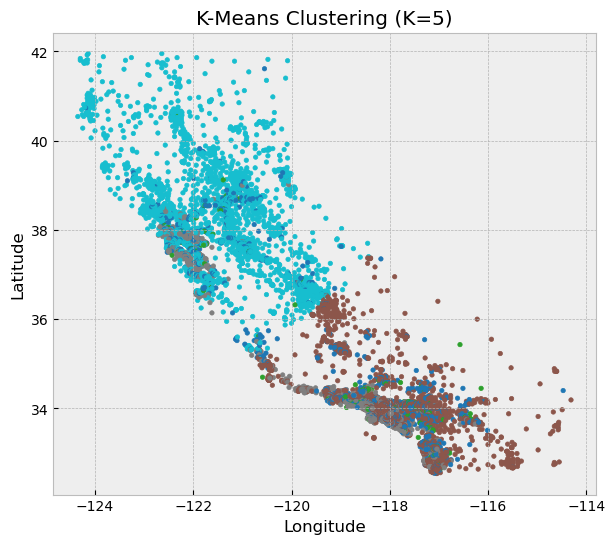

In [100]:
kmeans = KMeans(n_clusters=5, random_state=2025)
kmeans_labels = kmeans.fit_predict(scaled_data)

plt.figure(figsize=(7,6))
plt.scatter(features['longitude'], features['latitude'], c=kmeans_labels, cmap='tab10', s=10)
plt.title("K-Means Clustering (K=5)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


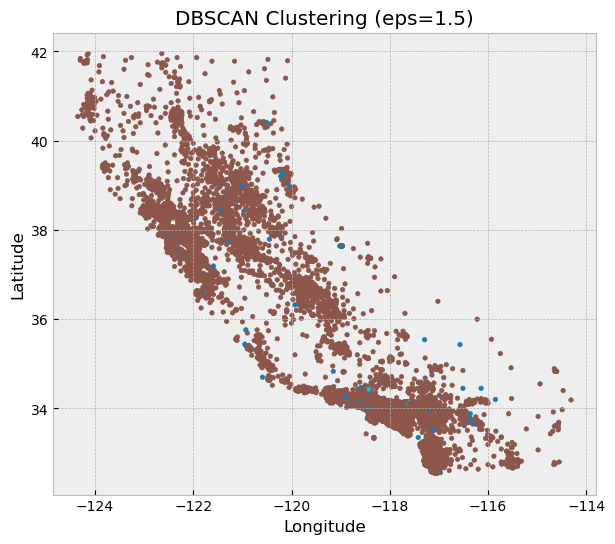

In [101]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)

plt.figure(figsize=(7,6))
plt.scatter(features['longitude'], features['latitude'], c=dbscan_labels, cmap='tab10', s=10)
plt.title("DBSCAN Clustering (eps=1.5)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [102]:
best_k = None
best_score = -1

for k in range(2, 10):  
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans_labels = kmeans.fit_predict(scaled_data)
    score = adjusted_rand_score(dbscan_labels, kmeans_labels)
    print(f"K={k}, Adjusted Rand Index = {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_k = k

print(f"\n Best K mean：{best_k}，it familiar with DBSCAN's ARI：{best_score:.4f}")


K=2, Adjusted Rand Index = -0.0024
K=3, Adjusted Rand Index = 0.0153
K=4, Adjusted Rand Index = 0.0101
K=5, Adjusted Rand Index = 0.0101
K=6, Adjusted Rand Index = 0.0075
K=7, Adjusted Rand Index = 0.0062
K=8, Adjusted Rand Index = 0.0045
K=9, Adjusted Rand Index = 0.0039

 Best K mean：3，it familiar with DBSCAN's ARI：0.0153


# Exercise 4 (14 points)

**In this problem you will be working with the [Motion Capture Hand Gesture Dataset](https://archive.ics.uci.edu/ml/datasets/Motion+Capture+Hand+Postures).**

> A Vicon motion capture camera system was used to record 12 users performing 5 hand postures with markers attached to a left-handed glove.

> A rigid pattern of markers on the back of the glove was used to establish a local coordinate system for the hand, and 11 other markers were attached to the thumb and fingers of the glove. 3 markers were attached to the thumb with one above the thumbnail and the other two on the knuckles. 2 markers were attached to each finger with one above the fingernail and the other on the joint between the proximal and middle phalanx.

> The 11 markers not part of the rigid pattern were unlabeled; their positions were not explicitly tracked. Consequently, there is no a priori correspondence between the markers of two given records. In addition, due to the resolution of the capture volume and self-occlusion due to the orientation and configuration of the hand and fingers, many records have missing markers. Extraneous markers were also possible due to artifacts in the Vicon software's marker reconstruction/recording process and other objects in the capture volume. As a result, the number of visible markers in a record varied considerably.

**Let's load the data:**

In [103]:
postures = pd.read_csv('postures.csv')
postures

,Class,User,X0,Y0,Z0,X1,Y1,Z1,X2,Y2,...,Z8,X9,Y9,Z9,X10,Y10,Z10,X11,Y11,Z11
0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,1,0,54.263880,71.466776,-64.807709,76.895635,42.462500,-72.780545,36.621229,81.680557,...,?,?,?,?,?,?,?,?,?,?
2,1,0,56.527558,72.266609,-61.935252,39.135978,82.538530,-49.596509,79.223743,43.254091,...,?,?,?,?,?,?,?,?,?,?
3,1,0,55.849928,72.469064,-62.562788,37.988804,82.631347,-50.606259,78.451526,43.567403,...,?,?,?,?,?,?,?,?,?,?
4,1,0,55.329647,71.707275,-63.688956,36.561863,81.868749,-52.752784,86.320630,68.214645,...,?,?,?,?,?,?,?,?,?,?
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78091,5,14,54.251127,129.177414,-44.252511,27.720784,107.810661,11.099282,-1.270139,122.758679,...,-6.54311453354464,87.7333643096221,61.2163626180662,-62.1262783028233,?,?,?,?,?,?
78092,5,14,54.334883,129.253842,-44.016320,27.767911,107.914808,11.069842,-30.334054,77.858214,...,-62.1305625712145,78.2298473919132,33.0784071753174,-45.2495433686171,?,?,?,?,?,?
78093,5,14,54.151540,129.269502,-44.173273,27.725978,108.034006,11.020347,-22.574718,104.222208,...,3.83590370588782,78.591554010542,32.32773753847,-46.1665560916632,?,?,?,?,?,?
78094,5,14,27.915311,108.007390,10.814957,-0.910435,122.464093,-47.271248,-30.084588,77.705861,...,-63.2216259324485,?,?,?,?,?,?,?,?,?


**As the dataset description notes, there are markers not being tracked. In the dataset, they are annotated as ```?```. Let's replace them with NaN.**

In [104]:
postures = postures.replace(to_replace='?', value=np.nan)

postures

,Class,User,X0,Y0,Z0,X1,Y1,Z1,X2,Y2,...,Z8,X9,Y9,Z9,X10,Y10,Z10,X11,Y11,Z11
0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
1,1,0,54.263880,71.466776,-64.807709,76.895635,42.462500,-72.780545,36.621229,81.680557,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,0,56.527558,72.266609,-61.935252,39.135978,82.538530,-49.596509,79.223743,43.254091,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,0,55.849928,72.469064,-62.562788,37.988804,82.631347,-50.606259,78.451526,43.567403,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,0,55.329647,71.707275,-63.688956,36.561863,81.868749,-52.752784,86.320630,68.214645,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78091,5,14,54.251127,129.177414,-44.252511,27.720784,107.810661,11.099282,-1.270139,122.758679,...,-6.54311453354464,87.7333643096221,61.2163626180662,-62.1262783028233,NaN,NaN,NaN,NaN,NaN,NaN
78092,5,14,54.334883,129.253842,-44.016320,27.767911,107.914808,11.069842,-30.334054,77.858214,...,-62.1305625712145,78.2298473919132,33.0784071753174,-45.2495433686171,NaN,NaN,NaN,NaN,NaN,NaN
78093,5,14,54.151540,129.269502,-44.173273,27.725978,108.034006,11.020347,-22.574718,104.222208,...,3.83590370588782,78.591554010542,32.32773753847,-46.1665560916632,NaN,NaN,NaN,NaN,NaN,NaN
78094,5,14,27.915311,108.007390,10.814957,-0.910435,122.464093,-47.271248,-30.084588,77.705861,...,-63.2216259324485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Moreover, let's consider only the relevant 11 markers:**

In [105]:
postures = postures[postures.columns[:11]]

postures

,Class,User,X0,Y0,Z0,X1,Y1,Z1,X2,Y2,Z2
0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,0,54.263880,71.466776,-64.807709,76.895635,42.462500,-72.780545,36.621229,81.680557,-52.919272
2,1,0,56.527558,72.266609,-61.935252,39.135978,82.538530,-49.596509,79.223743,43.254091,-69.982489
3,1,0,55.849928,72.469064,-62.562788,37.988804,82.631347,-50.606259,78.451526,43.567403,-70.658489
4,1,0,55.329647,71.707275,-63.688956,36.561863,81.868749,-52.752784,86.320630,68.214645,-72.228461
...,...,...,...,...,...,...,...,...,...,...,...
78091,5,14,54.251127,129.177414,-44.252511,27.720784,107.810661,11.099282,-1.270139,122.758679,-46.460186
78092,5,14,54.334883,129.253842,-44.016320,27.767911,107.914808,11.069842,-30.334054,77.858214,-17.002723
78093,5,14,54.151540,129.269502,-44.173273,27.725978,108.034006,11.020347,-22.574718,104.222208,-53.939140
78094,5,14,27.915311,108.007390,10.814957,-0.910435,122.464093,-47.271248,-30.084588,77.705861,-17.460853


**Use this cleaned dataset to answer the following questions:**

1. (10 points) **Train 2 different clustering algorithms to perform hand gesture classification.**

    * **Do not forget the standard steps (imputer, scaling, dropping unnecessary attributes, etc.) prior to training the clustering algorithm.**

2. (4 points) **Report internal and external clustering validity measures on your results.**

In [106]:
X = postures.drop(columns=['Class', 'User'])
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
true_labels = postures['Class']

Model1 K mean

In [107]:
kmeans = KMeans(n_clusters=2, random_state=2025)
kmeans_labels = kmeans.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
dbi_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ari_kmeans = adjusted_rand_score(true_labels, kmeans_labels)
nmi_kmeans = normalized_mutual_info_score(true_labels, kmeans_labels)


Model2 DBSCAN

In [108]:
dbscan = DBSCAN(eps=1.2, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

valid_idx = dbscan_labels != -1
if valid_idx.sum() > 0:
    sil_dbscan = silhouette_score(X_scaled[valid_idx], dbscan_labels[valid_idx])
    dbi_dbscan = davies_bouldin_score(X_scaled[valid_idx], dbscan_labels[valid_idx])
else:
    sil_dbscan = dbi_dbscan = None

ari_dbscan = adjusted_rand_score(true_labels, dbscan_labels)
nmi_dbscan = normalized_mutual_info_score(true_labels, dbscan_labels)


Summarize internal and external clustering validity measures on your results.

In [109]:
print("=== KMeans Results ===")
print(f"Silhouette Score: {sil_kmeans:.4f}")
print(f"Davies-Bouldin Index: {dbi_kmeans:.4f}")
print(f"ARI: {ari_kmeans:.4f}")
print(f"NMI: {nmi_kmeans:.4f}")

print("\n=== DBSCAN Results ===")
print(f"Silhouette Score: {sil_dbscan if sil_dbscan is not None else 'N/A'}")
print(f"Davies-Bouldin Index: {dbi_dbscan if dbi_dbscan is not None else 'N/A'}")
print(f"ARI: {ari_dbscan:.4f}")
print(f"NMI: {nmi_dbscan:.4f}")


=== KMeans Results ===
Silhouette Score: 0.1950
Davies-Bouldin Index: 1.8716
ARI: 0.1105
NMI: 0.1366

=== DBSCAN Results ===
Silhouette Score: -0.32479982485407677
Davies-Bouldin Index: 0.8190291321770861
ARI: -0.0004
NMI: 0.0505


From Silhouette score and Davied-Bouldin Index, we can conclude that although KMeans had a slightly higher Silhouette Score, its Davies-Bouldin Index is much worse, indicating poorer separation between clusters. DBSCAN provides better internal validity overall, especially for datasets that may have non-spherical clusters or noise.

In terms of external validation, DBSCAN outperforms KMeans on both ARI and NMI, indicating better alignment with the ground-truth classes. Especially NMI (0.33 vs. 0.15) shows that DBSCAN captured more meaningful structure.

___

___

# Submit Your Solution

Confirm that you've successfully completed the assignment.

Along with the Notebook, include a PDF of the notebook with your solutions.

```add``` and ```commit``` the final version of your work, and ```push``` your code to your GitHub repository.

Submit the URL of your GitHub Repository as your assignment submission on Canvas.

___